ANALSIS UNIVARIADO

Gasto_Mensual_USD
Media: 65.74
Mediana: 50.30
Desviacion estandar: 44.71
Q1: 34.12
Q3: 86.87
IQR: 52.75
Sesgo: 1.67

Soporte_Tickets

Gasto_Mensual_USD
Media: 1.96
Mediana: 2.00
Desviacion estandar: 1.32
Q1: 1.00
Q3: 3.00
IQR: 2.00
Sesgo: 0.54


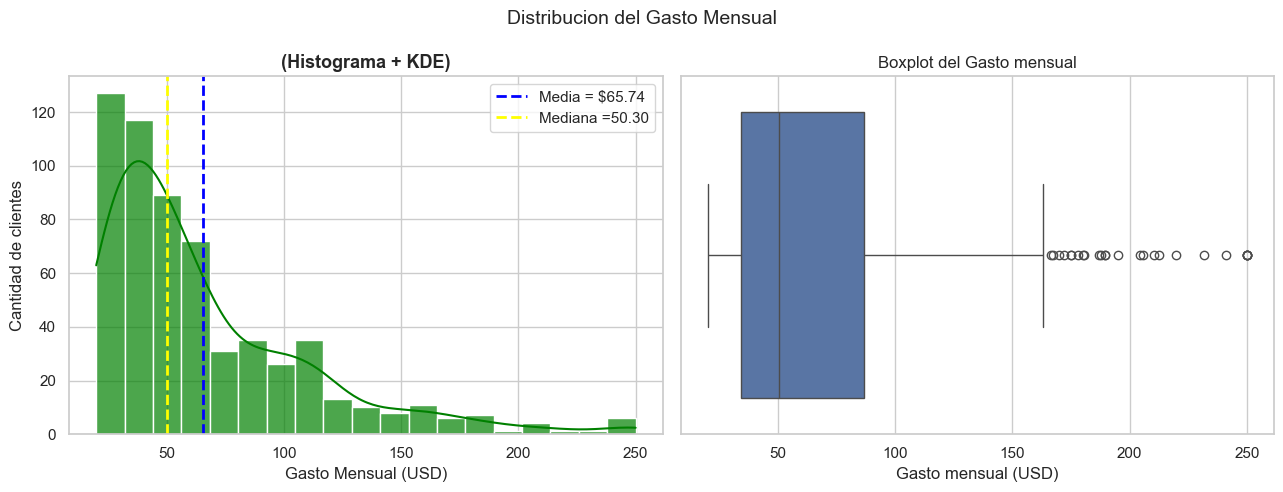

ANALISIS BIVARIADO

Tasa de cancelacion por metodo de pago:
     Metodo_Pago  tasa_cancelacion_pct  cancelaciones  clientes
0       Efectivo                 23.64             26       110
1        Tarjeta                 12.94             37       286
2  Transferencia                 13.24             27       204


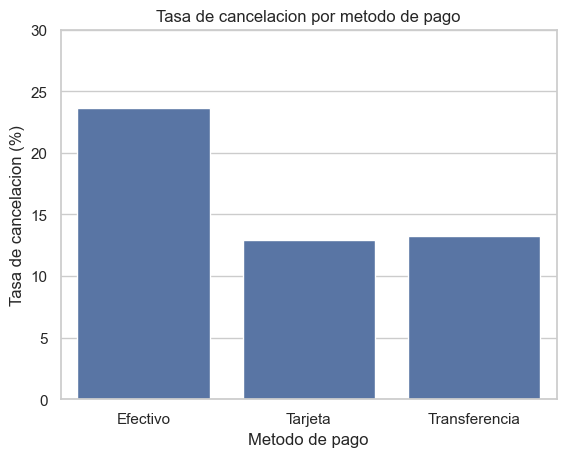


Matriz de correlacion de Pearson:
                   Antiguedad_Meses  Gasto_Mensual_USD  Soporte_Tickets  \
Antiguedad_Meses               1.00              -0.01            -0.09   
Gasto_Mensual_USD             -0.01               1.00            -0.04   
Soporte_Tickets               -0.09              -0.04             1.00   
Cancelo_Servicio              -0.13               0.03             0.21   

                   Cancelo_Servicio  
Antiguedad_Meses              -0.13  
Gasto_Mensual_USD              0.03  
Soporte_Tickets                0.21  
Cancelo_Servicio               1.00  

ANALISIS MULTIVARIADO Y AGRUPACION

Promedio, mediana y cantidad de clientee por Metodo_Pago y Cancelacion
     Metodo_Pago  Cancelo_Servicio  promedio  mediana  cantidad_clientes
0       Efectivo                 0     74.56    48.18                 84
1       Efectivo                 1     78.36    67.96                 26
2        Tarjeta                 0     63.87    49.18                249

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<?, ?it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
import seaborn as sns 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from ydata_profiling import ProfileReport

sns.set_theme(style="whitegrid") 
np.random.seed(101) 
n = 600 
  
df_churn = pd.DataFrame({ 
    "Cliente_ID": [f"CLI-{i:05d}" for i in range(1, n + 1)], 
    "Antiguedad_Meses": np.random.randint(1, 72, size=n), 
 # genera numeros enteros aleatorios 
    "Gasto_Mensual_USD": np.clip(np.random.exponential(scale=45, size=n) + 20, 20, 250), 
 # np.clip(..., 20, 250) obliga a que los gastos permanezcan entre 20 y 250 USD 
    "Soporte_Tickets": np.random.poisson(lam=2, size=n), 
 # genera numeros aleatorios con distribución de poisson, la media de tickets será 2 
    "Metodo_Pago": np.random.choice( 
        ["Tarjeta", "Efectivo", "Transferencia"], size=n, 
        p=[0.50, 0.20, 0.30] 
    ) 
}) 
  
# Probabilidad de cancelación con patrones analizables 
logit = (-2.0 
         + 0.38 * df_churn["Soporte_Tickets"] 
         - 0.018 * df_churn["Antiguedad_Meses"] 
         + 0.35 * (df_churn["Metodo_Pago"] == "Efectivo")) 
prob_cancelacion = 1 / (1 + np.exp(-logit)) 
df_churn["Cancelo_Servicio"] = np.random.binomial(1, prob_cancelacion) 
  
df_churn["Gasto_Mensual_USD"] = df_churn["Gasto_Mensual_USD"].round(2) 
  
df_churn.head() 


#1. Analisis univariado
# Para Gasto_Mensual_USD y Soporte_Tickets calculen media, mediana, desviación estándar, Q1, Q3, IQR y sesgo.

print("ANALSIS UNIVARIADO")
gasto=df_churn["Gasto_Mensual_USD"]
print("\nGasto_Mensual_USD")
print(f"Media: {gasto.mean():.2f}")
print(f"Mediana: {gasto.median():.2f}")
print(f"Desviacion estandar: {gasto.std():.2f}")
print(f"Q1: {gasto.quantile(0.25):.2f}")
print(f"Q3: {gasto.quantile(0.75):.2f}")
print(f"IQR: {gasto.quantile(0.75)-gasto.quantile(0.25):.2f}")
print(f"Sesgo: {gasto.skew():.2f}")


print("\nSoporte_Tickets")
tickets=df_churn["Soporte_Tickets"]
print("\nGasto_Mensual_USD")
print(f"Media: {tickets.mean():.2f}")
print(f"Mediana: {tickets.median():.2f}")
print(f"Desviacion estandar: {tickets.std():.2f}")
print(f"Q1: {tickets.quantile(0.25):.2f}")
print(f"Q3: {tickets.quantile(0.75):.2f}")
print(f"IQR: {tickets.quantile(0.75)-tickets.quantile(0.25):.2f}")
print(f"Sesgo: {tickets.skew():.2f}")


#construir para gasto_mensual_usd un histograma con kde y un boxplot
fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('Distribucion del Gasto Mensual',fontsize=14)

sns.histplot(gasto,kde=True,ax=axes[0],color='green',alpha=0.70,edgecolor='white')
axes[0].set_title("(Histograma + KDE)",fontsize=13,fontweight='bold') 
axes[0].set_xlabel("Gasto Mensual (USD)")
axes[0].set_ylabel("Cantidad de clientes")
axes[0].axvline(gasto.mean(),color='blue',linestyle="--",linewidth=2,label=f"Media = ${gasto.mean():.2f}")#linea de media
axes[0].axvline(gasto.median(),color='yellow',linestyle="--",linewidth=2,label=f"Mediana ={gasto.median():.2f}")
axes[0].legend()
sns.boxplot(x=gasto,ax=axes[1])
axes[1].set_title('Boxplot del Gasto mensual')
axes[1].set_xlabel("Gasto mensual (USD)")
plt.tight_layout()
plt.show()

#2. Analisis bivariado 
#grafico de barras para la variable categórica Metodo_Pago
print("ANALISIS BIVARIADO")
cancelacion_metodo=(df_churn.groupby("Metodo_Pago")["Cancelo_Servicio"].agg(tasa_cancelacion="mean",cancelaciones="sum",clientes="count").reset_index())
cancelacion_metodo["tasa_cancelacion_pct"]=cancelacion_metodo["tasa_cancelacion"]*100
print("\nTasa de cancelacion por metodo de pago:")
print(cancelacion_metodo[["Metodo_Pago","tasa_cancelacion_pct","cancelaciones","clientes"]].round(2))
sns.barplot(data=cancelacion_metodo,x="Metodo_Pago",y="tasa_cancelacion_pct",errorbar=None)
plt.title("Tasa de cancelacion por metodo de pago")
plt.xlabel("Metodo de pago")
plt.ylabel("Tasa de cancelacion (%)")
plt.ylim(0,30)
plt.show()

#matriz de correlacion de pearson
variable_corr=["Antiguedad_Meses","Gasto_Mensual_USD","Soporte_Tickets","Cancelo_Servicio"]
matriz_correlacion=df_churn[variable_corr].corr(method="pearson")
print("\nMatriz de correlacion de Pearson:")
print(matriz_correlacion.round(2))


#3. Analisis multivariado 
print("\nANALISIS MULTIVARIADO Y AGRUPACION")
groupby=df_churn.groupby(['Metodo_Pago','Cancelo_Servicio'])['Gasto_Mensual_USD'].agg(promedio='mean',mediana='median',cantidad_clientes='count').reset_index()

print("\nPromedio, mediana y cantidad de clientee por Metodo_Pago y Cancelacion")
print(groupby.round(2))

#4. Reporte AutoEDA
print("Reporte interactivo de AutoEDA con ydata-profiling")
profile=ProfileReport(df_churn,title='Reporte autoEda - Diagnostico de cancelacion de clientes',explorative=True,)
profile.to_notebook_iframe()
profile.to_file(" Reporte_AutoEDA.html")




# Reporte EDA de clientes

## Resumen ejecutivo

El analisis exploratorio de **600 clientes** permitio identificar patrones relacionados con el gasto mensual, los tickets de soporte, el metodo de pago y la cancelacion del servicio. El gasto mensual presenta una distribucion con asimetria positiva, por lo que la mediana resulta mas representativa que la media. Ademas, el metodo de pago en efectivo presenta la mayor tasa de cancelacion. Finalmente, existe una relacion positiva debil entre los tickets de soporte y la cancelacion del servicio.

## Tres hallazgos

### 1. Hallazgo univariado
El gasto mensual presenta un sesgo positivo de **1.67**. La media es de **$65.74** y la mediana de **$50.30**. Por la asimetria de la distribucion, la mediana representa mejor el gasto tipico.

### 2. Hallazgo bivariado
Los clientes que utilizan **efectivo** presentan la mayor tasa de cancelacion, con **23.64%**, frente a **12.94%** para tarjeta y **13.24%** para transferencia. Ademas, `Soporte_Tickets` y `Cancelo_Servicio` presentan una correlacion positiva débil (**r = 0.21**).

### 3. Hallazgo multivariado
El segmento **Efectivo + cancelo** merece revision prioritaria. Su tasa de cancelacion es de **23.64%** y su gasto mensual promedio entre los clientes que cancelaron es de **$78.36**, el mayor de los tres metodos de pago.

## Recomendaciones para el negocio

1. **Priorizar la revision del segmento que utiliza efectivo**, debido a su tasa de cancelación de **23.64%**, superior a la observada en tarjeta y transferencia. Se recomienda investigar si existen dificultades o caracteristicas particulares asociadas a este metodo de pago.

2. **Analizar las causas de los tickets de soporte**, especialmente en clientes con mayor numero de solicitudes, debido a la correlacion positiva debil de **r = 0.21** entre tickets y cancelacion. Esto puede ayudar a detectar problemas de experiencia del cliente y oportunidades de mejora.